In [1]:


from src.constants import STATIONS_PCR
from src.paths import (
    FORCING_PCRGLOB,
    INI_FILES,
    LOAD_PCR,
    OUTPUT_PCRGLOB,
    PCR_GLOBAL_PARAMS,
    PCR_TAIL,
)

import ewatercycle.forcing
import ewatercycle.models
import ewatercycle.observation.grdc
import ewatercycle.parameter_sets
from ewatercycle.container import ContainerImage

from datetime import datetime

import pandas as pd
from tqdm.notebook import tqdm
from rich import print
from pathlib import Path


/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


In [2]:
pcr_glob_directory = PCR_GLOBAL_PARAMS  # GlobalOption uit .ini
prepared_pcr_forcing = FORCING_PCRGLOB / LOAD_PCR / PCR_TAIL

In [3]:
parameter_set_basin = ewatercycle.parameter_sets.ParameterSet(
    name="custom_parameter_set",
    directory=pcr_glob_directory,
    config=INI_FILES / "test_comp_speed_full.ini",
    target_model="pcrglobwb",
    supported_model_versions={"17feb"},
)

parameter_set_basin_path = ewatercycle.parameter_sets.ParameterSet(
    name="custom_parameter_set",
    directory=pcr_glob_directory,
    config=INI_FILES / "test_comp_speed_basin_path.ini",
    target_model="pcrglobwb",
    supported_model_versions={"17feb"},
)

forcing = ewatercycle.forcing.sources["PCRGlobWBForcing"].load(
    directory=prepared_pcr_forcing,
)

In [4]:
my_image = ContainerImage("/home/avandervee3/ewatercycle_pcr_17feb.sif")
my_image.version

'17feb'

In [5]:
# Custom PCRGlobWB wrapper to support custom cloneMap and landmask
from ewatercycle_pcrglobwb.model import PCRGlobWB
from pydantic import model_validator
from typing import Optional
from pathlib import Path
from ewatercycle.util import to_absolute_path

class PCRGlobWBCustom(PCRGlobWB):
    """Extended PCRGlobWB with support for custom cloneMap and landmask paths."""

    cloneMap: Optional[Path] = None
    landmask: Optional[Path] = None

    @model_validator(mode="after")
    def _check_parameter_set(self):
        if not self.parameter_set:
            return self

        target_model = self.parameter_set.target_model.lower()
        if target_model != "pcrglobwb":
            msg = (
                "Parameter set has wrong target model, "
                f"expected pcrglobwb got {target_model}"
            )
            raise ValueError(msg)

        version = self.version
        ps_versions = self.parameter_set.supported_model_versions
        if version and ps_versions and version not in ps_versions:
            msg = (
                f"Parameter set '{self.parameter_set.name}' not compatible"
                f" with this model version.\nModel version: {version}. "
                f"Compatible versions: {ps_versions}"
            )
            raise ValueError(msg)

        return self

    def _resolve_path(self, path: Path) -> Path:
        if path.is_absolute():
            return to_absolute_path(path, must_be_in_parent=False)
        return to_absolute_path(
            path, parent=self.parameter_set.directory, must_be_in_parent=True
        )

    @model_validator(mode="after")
    def _initialize_config(self: "PCRGlobWBCustom") -> "PCRGlobWBCustom":
        cfg = super()._initialize_config()._config

        if self.cloneMap:
            clone_map_abs = str(self._resolve_path(self.cloneMap))
            cfg.set("globalOptions", "cloneMap", clone_map_abs)

        if self.landmask:
            landmask_abs = str(self._resolve_path(self.landmask))
            cfg.set("globalOptions", "landmask", landmask_abs)

        self._config = cfg
        return self

    def _make_bmi_instance(self):
        if self.cloneMap:
            clone_dir = str(Path(self.cloneMap).parent)
            if clone_dir not in self._additional_input_dirs:
                self._additional_input_dirs.append(clone_dir)

        if self.landmask:
            landmask_dir = str(Path(self.landmask).parent)
            if landmask_dir not in self._additional_input_dirs:
                self._additional_input_dirs.append(landmask_dir)

        return super()._make_bmi_instance()


In [6]:
# tools_folder = Path("/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/tools")

# rivers = tools_folder / "aral_basin_ad_sd_rivers_buffer_05min_mask.map"
# rivers_edge = tools_folder / "aral_basin_ad_sd_rivers_buffer_05min_mask_edge.map"
# rivers_buffer = tools_folder / "aral_basin_ad_sd_rivers_buffer_05min_mask.map"
# rivers_buffer_10km = tools_folder / "aral_basin_ad_sd_rivers_buffer_10_05min_mask.map"


# reference = PCRGlobWBCustom(
#     parameter_set=parameter_set_basin, forcing=forcing, bmi_image=my_image
# )

# path_to_file = PCRGlobWBCustom(
#     parameter_set=parameter_set_basin_path, 
#     forcing=forcing, 
#     bmi_image=my_image,
#     cloneMap=rivers,
#     landmask=rivers
# )

# path_to_file = PCRGlobWBCustom(
#     parameter_set=parameter_set_basin_path, 
#     forcing=forcing, 
#     bmi_image=my_image,
#     cloneMap=rivers_edge,
#     landmask=rivers_edge
# )

# path_to_file = PCRGlobWBCustom(
#     parameter_set=parameter_set_basin_path, 
#     forcing=forcing, 
#     bmi_image=my_image,
#     cloneMap=rivers_buffer,
#     landmask=rivers_buffer
# )

# path_to_file = PCRGlobWBCustom(
#     parameter_set=parameter_set_basin_path, 
#     forcing=forcing, 
#     bmi_image=my_image,
#     cloneMap=rivers_buffer_10km,
#     landmask=rivers_buffer_10km
# )

In [7]:
experiment_start_date = "1949-10-01T00:00:00Z"
experiment_end_date = "1950-06-30T00:00:00Z"

In [8]:
# reference_config, reference_dir = reference.setup(
#     cfg_dir=OUTPUT_PCRGLOB / "path_standard",
#     start_time=experiment_start_date,
#     end_time=experiment_end_date,
#     max_spinups_in_years=0,
# )
# reference_config, reference_dir

# reference_2x_config, reference_2x_dir = path_to_file.setup(
#     cfg_dir=OUTPUT_PCRGLOB / "path_to_file",
#     start_time=experiment_start_date,
#     end_time=experiment_end_date,
#     max_spinups_in_years=0,
# )
# reference_2x_config, reference_2x_dir

In [9]:
tools_folder = Path("/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/tools")

rivers = tools_folder / "aral_basin_ad_sd_rivers_buffer_05min_mask.map"
rivers_edge = tools_folder / "aral_basin_ad_sd_rivers_edge_05min_mask.map"
rivers_buffer = tools_folder / "aral_basin_ad_sd_rivers_buffer_05min_mask.map"
rivers_buffer_10km = tools_folder / "aral_basin_ad_sd_rivers_buffer_10_05min_mask.map"

total_area = tools_folder / "aral_basin_05min.map"

# Dictionary to store all experiments, make None to later overwrite with the actual experiment instances
experiments = {
    "reference": None,
    "rivers": None,
    "rivers_edge": None,
    "rivers_buffer": None,
    "rivers_buffer_10km": None,
    "rivers_edge_clone":None,
    "rivers_buffer_clone": None,

}

In [10]:
# Create model instances for each experiment
# Reference model (no custom cloneMap/landmask)
experiments["reference"] = PCRGlobWBCustom(
    parameter_set=parameter_set_basin, forcing=forcing, bmi_image=my_image
)

# Models with different mask files
experiments["rivers"] = PCRGlobWBCustom(
    parameter_set=parameter_set_basin_path, 
    forcing=forcing, 
    bmi_image=my_image,
    cloneMap=rivers,
    landmask=rivers
)

experiments["rivers_edge"] = PCRGlobWBCustom(
    parameter_set=parameter_set_basin_path, 
    forcing=forcing, 
    bmi_image=my_image,
    cloneMap=rivers_edge,
    landmask=rivers_edge
)

experiments["rivers_buffer"] = PCRGlobWBCustom(
    parameter_set=parameter_set_basin_path, 
    forcing=forcing, 
    bmi_image=my_image,
    cloneMap=rivers_buffer,
    landmask=rivers_buffer
)

experiments["rivers_buffer_10km"] = PCRGlobWBCustom(
    parameter_set=parameter_set_basin_path, 
    forcing=forcing, 
    bmi_image=my_image,
    cloneMap=rivers_buffer_10km,
    landmask=rivers_buffer_10km
)

experiments["rivers_edge_clone"] = PCRGlobWBCustom(
    parameter_set=parameter_set_basin, 
    forcing=forcing, 
    bmi_image=my_image,
    #cloneMap=total_area,
    #landmask=rivers_edge
)

experiments["rivers_buffer_clone"] = PCRGlobWBCustom(
    parameter_set=parameter_set_basin, 
    forcing=forcing, 
    bmi_image=my_image,
    #cloneMap=total_area,
    #landmask=rivers_buffer_10km
)

print("Created experiments:", list(experiments.keys()))

Created experiments:
[
    'reference',
    'rivers',
    'rivers_edge',
    'rivers_buffer',
    'rivers_buffer_10km',
    'rivers_edge_clone',
    'rivers_buffer_clone'
]

In [11]:
# Dictionary to store configs and directories for each experiment
experiment_configs = {}
experiment_dirs = {}

# Run setup for each experiment
for exp_name, model in experiments.items():
    print(f"\nSetting up experiment: {exp_name}")
    
    config, directory = model.setup(
        cfg_dir=OUTPUT_PCRGLOB / "experiments_march02c"/ exp_name,
        start_time=experiment_start_date,
        end_time=experiment_end_date,
        max_spinups_in_years=0,
    )
    
    experiment_configs[exp_name] = config
    experiment_dirs[exp_name] = directory
    

print("\n✓ All experiments setup complete!")
print(f"Experiment configs: {list(experiment_configs.keys())}")
print(f"Experiment directories: {list(experiment_dirs.keys())}")

Setting up experiment: reference

Setting up experiment: rivers

Setting up experiment: rivers_edge

Setting up experiment: rivers_buffer

Setting up experiment: rivers_buffer_10km

Setting up experiment: rivers_edge_clone

Setting up experiment: rivers_buffer_clone

✓ All experiments setup complete!

Experiment configs: ['reference', 'rivers', 'rivers_edge', 'rivers_buffer', 'rivers_buffer_10km', 
'rivers_edge_clone', 'rivers_buffer_clone']

Experiment directories: ['reference', 'rivers', 'rivers_edge', 'rivers_buffer', 'rivers_buffer_10km', 
'rivers_edge_clone', 'rivers_buffer_clone']

In [12]:
print(experiments["reference"].parameters)

refence_para = experiments["reference"].parameters

# Convert ISO 8601 strings to datetime objects
start_time = datetime.strptime(experiment_start_date, "%Y-%m-%dT%H:%M:%SZ")
end_time = datetime.strptime(experiment_end_date, "%Y-%m-%dT%H:%M:%SZ")

# Calculate the number of days for the progression bar
delta = end_time - start_time
number_of_days = delta.days
print(f"Number of days to model: {number_of_days}")

dict_items([('start_time', '1949-10-01T00:00:00Z'), ('end_time', '1950-06-30T00:00:00Z'), ('routing_method', 
'accuTravelTime'), ('max_spinups_in_years', '0')])

Number of days to model: 272

In [13]:
# reference.initialize(reference_config)
# path_to_file.initialize(reference_2x_config)

In [14]:
# Initialize all experiments
for exp_name, model in experiments.items():
    print(f"Initializing experiment: {exp_name}")
    model.initialize(experiment_configs[exp_name])

print("\n✓ All experiments initialized!")

Initializing experiment: reference

Initializing experiment: rivers

Initializing experiment: rivers_edge

Initializing experiment: rivers_buffer

Initializing experiment: rivers_buffer_10km

Initializing experiment: rivers_edge_clone

Initializing experiment: rivers_buffer_clone

✓ All experiments initialized!

In [15]:
# time = pd.date_range(reference.start_time_as_isostr, reference.end_time_as_isostr)
# stations_timeseries = pd.DataFrame(
#     index=pd.Index(time, name="time"), columns=["Chatly", "Kerki", "Tyumen", "Kazalinsk"]
# )
# stations_timeseries.head()


# stations_discharge_reference = stations_timeseries.copy()
# stations_discharge_reference_2x = stations_timeseries.copy()

# stations_channelstorage_reference = stations_timeseries.copy()
# stations_channelstorage_reference_2x = stations_timeseries.copy()

In [16]:
# for _ in tqdm(range(number_of_days), desc="Running model"):
#     reference.update()






# print("Model run finished!")

In [17]:
# # Dictionary to store discharge timeseries for all experiments
# experiments_discharge = {}

# # # Initialize dataframes for each experiment
# # for exp_name in experiments.keys():
# #     experiments_discharge[exp_name] = pd.DataFrame(
# #         index=pd.Index(time, name="time"), 
# #         columns=STATIONS_PCR.keys()
# #     )

# #print(f"Running {number_of_days} days for {len(experiments)} experiments")
# #print(f"{'='*60}")

# # Run all experiments in parallel for each day
# for day in tqdm(range(number_of_days), desc="Running all experiments"):
#     # Update all models for this day
#     for exp_name, model in experiments.items():
#         model.update()





In [18]:
from concurrent.futures import ThreadPoolExecutor

for day in tqdm(range(number_of_days), desc="Running all experiments"):
    with ThreadPoolExecutor(max_workers=3) as executor:              #max_workers=3
        futures = [executor.submit(model.update) for model in experiments.values()]
        for future in futures:
            future.result(

Running all experiments:   0%|          | 0/272 [00:00<?, ?it/s]

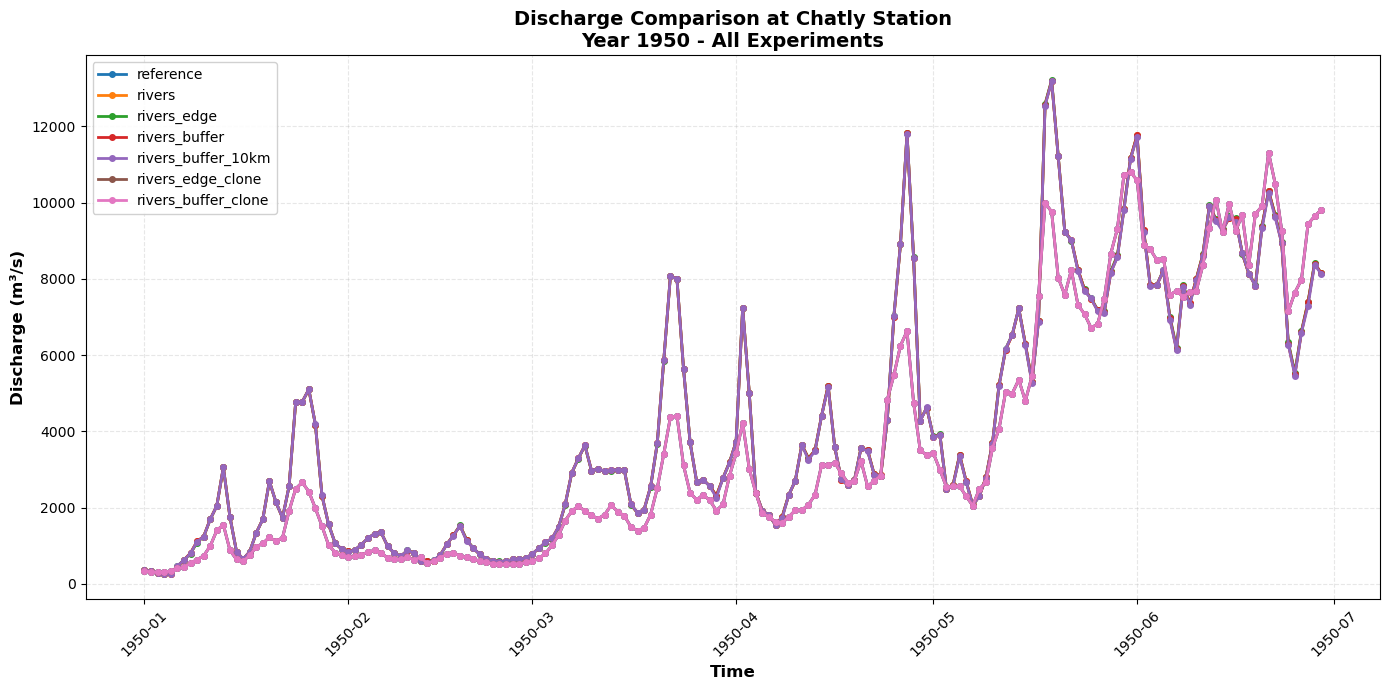

Experiments plotted: ['reference', 'rivers', 'rivers_edge', 'rivers_buffer', 'rivers_buffer_10km', 
'rivers_edge_clone', 'rivers_buffer_clone']

In [19]:
# Load discharge data from NetCDF files for all experiments and plot Chatly station
import xarray as xr
import matplotlib.pyplot as plt

# Define the base path and station
base_path = OUTPUT_PCRGLOB / "experiments_march02c"
station_name = "Chatly"
station_coords = STATIONS_PCR[station_name]

# Select year to plot
selected_year = 1950  # Change to 1949 or 1950

# Create figure
fig, ax = plt.subplots(figsize=(14, 7))

# Dictionary to store time series for each experiment
experiment_timeseries = {}

# Load and plot discharge for each experiment
for exp_name in experiments.keys():
    nc_file = base_path / exp_name / "netcdf" / "discharge_dailyTot_output.nc"
    
    
    if nc_file.exists():
        # Load the NetCDF file
        ds = xr.open_dataset(nc_file)
        
        # Get discharge at station location (nearest neighbor)
        discharge_at_station = ds['discharge'].sel(
            lat=station_coords['lat'], 
            lon=station_coords['lon'], 
            method='nearest'
        )
        
        # Extract time and values
        time_idx = discharge_at_station.time.values
        discharge_vals = discharge_at_station.values
        
        # Convert to datetime
        time_dates = pd.to_datetime(time_idx)
        
        # Filter by selected year
        year_mask = time_dates.year == selected_year
        time_dates_filtered = time_dates[year_mask]
        discharge_vals_filtered = discharge_vals[year_mask]
        
        # Store in dictionary
        experiment_timeseries[exp_name] = pd.Series(discharge_vals_filtered, index=time_dates_filtered)
        
        # Plot
        ax.plot(time_dates_filtered, discharge_vals_filtered, marker='o', label=exp_name, linewidth=2, markersize=4)
        
        ds.close()
    else:
        print(f"File not found: {nc_file}")

# Formatting
ax.set_xlabel('Time', fontsize=12, fontweight='bold')
ax.set_ylabel('Discharge (m³/s)', fontsize=12, fontweight='bold')
ax.set_title(f'Discharge Comparison at {station_name} Station\nYear {selected_year} - All Experiments', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


print(f"Experiments plotted: {list(experiment_timeseries.keys())}")


In [20]:
# Convert experiment_timeseries dictionary to DataFrame
experiment_df = pd.DataFrame(experiment_timeseries)

experiment_df.head()

,reference,rivers,rivers_edge,rivers_buffer,rivers_buffer_10km,rivers_edge_clone,rivers_buffer_clone
1950-01-01,339.345917,366.318878,362.728149,366.318878,367.426117,339.345917,339.345917
1950-01-02,315.434967,328.832092,328.043762,328.832092,331.050964,315.434967,315.434967
1950-01-03,307.532257,284.427490,284.691254,284.427490,286.963989,307.532257,307.532257
1950-01-04,309.664551,259.870544,263.320404,259.870544,261.301147,309.664551,309.664551
1950-01-05,342.250336,272.216187,278.667847,272.216187,273.035797,342.250336,342.250336


In [21]:
# for _ in tqdm(range(number_of_days), desc="Running model"):
#     path_to_file.update()

#     for station_name, coords in STATIONS_PCR.items():
#         discharge_getvalue = path_to_file.get_value_at_coords(
#             "discharge",
#             lat=[coords["lat"]],
#             lon=[coords["lon"]],
#         )

#         stations_discharge_reference_2x.loc[time, station_name] = discharge_getvalue[0]

In [ ]:
KerkiK

NameError: name 'discharge_exp1' is not defined

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt

# Load the NetCDF file
dataset = xr.open_dataset(discharge_exp1)

# Inspect the structure
print(dataset)

# Plot a variable (adjust variable name as needed)
dataset['discharge'].plot()
plt.show()

In [ ]:
# Or create a spatial map for a specific time
dataset['discharge'].isel(time=-1).plot()